<a href="https://colab.research.google.com/github/micplachta/um2026/blob/main/lab02_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment: EM Clustering in 2D**
-------------------------------

You have seen how the **Expectation-Maximization (EM)** algorithm can fit a Gaussian Mixture Model (GMM) to a 2D dataset. You should now explore:

## **Primary Question**

**How can we visualize the *decision boundary* for attributing a *new* (unlabeled) point to one of the GMM clusters?**  

In other words, given a 2D data distribution modeled by EM, think of a way to clearly show (on a plot) *which* cluster a point would be assigned to (or which cluster has the highest responsibility (posterior probability) for that point)?  

The plot should comprehensively cover the entire visible region, ensuring that for any point on the plot, it is immediately evident which cluster it would belong to. You can plot **lines** separating clusters or use a **color map** showing each point's "most likely cluster" (use at least 1000 points).

You can illustrate your approach with **the same** 2D dataset that we used in class, or you can find another suitable 2D dataset, it's up to you. Note however, that having 3 clusters enhances the clarity of the visualization—while 2 clusters result in overly simple boundaries, using 4 or more clusters can make the entire plot difficult to interpret. Try to choose a dataset with 3 clusters.

Discuss any irregularities observed in the resulting plot. If a decision boundary suggests that a region should be attributed to a cluster in a counterintuitive way (we saw it in class!), provide an explanation for why this might occur. It may be also an indication you have a bug in your code.

## **Secondary Question**

**If we *didn't know* the number of clusters in advance, how could we decide on a suitable $K$ for the clustering algorithm?**  

You would need an evaluation metrics, right? Experiment with inertia and silhoutte scores (and other metrics, if you'd like) and show the resulting plots.

You can illustrate your approach with **the same** dataset as in the primary question by trying different values of $K$. Or you can find another suitable dataset, it's up to you. Note, that the dataset doesn't need to be 2D in this task.


## **Task & Deliverables**

1. **Colab Notebook**  
   - Create a **Colab notebook** that:
     - Clearly **answers** both the **primary** and **secondary** questions with appropriate plots and short explanations.
     - Uses Python code (e.g. `scikit-learn` for GMM) to visualize:
       1. The **data** and **cluster assignments**.
       2. The **decision boundary** (lines or a color map) indicating each cluster's region.
       3. A demonstration of how you would pick a suitable number of clusters $K$ when it is not known, with plots.
   - Remember to use the `$` symbol to delimit **inline equations** and `$$` to delimit **full-line equations**.

2. **Publish on GitHub**  
   - Place the Colab notebook in your **GitHub repository** for this course.
   - In your repository’s **README**, add a **link** to the notebook and also include an **“Open in Colab”** badge at the top of the notebook so it can be launched directly from GitHub.



In [52]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# Generate data the same way as during classes
np.random.seed(0)

mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.16, 0.0],
                 [0.0,  0.16]])
data1 = np.random.multivariate_normal(mean1, cov1, 300)

mean2 = np.array([0.8, 0.8])
cov2 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data2 = np.random.multivariate_normal(mean2, cov2, 100)

mean3 = np.array([-0.8, 0.8])
cov3 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data3 = np.random.multivariate_normal(mean3, cov3, 100)

data_X = np.vstack([data1, data2, data3])

### Task 1

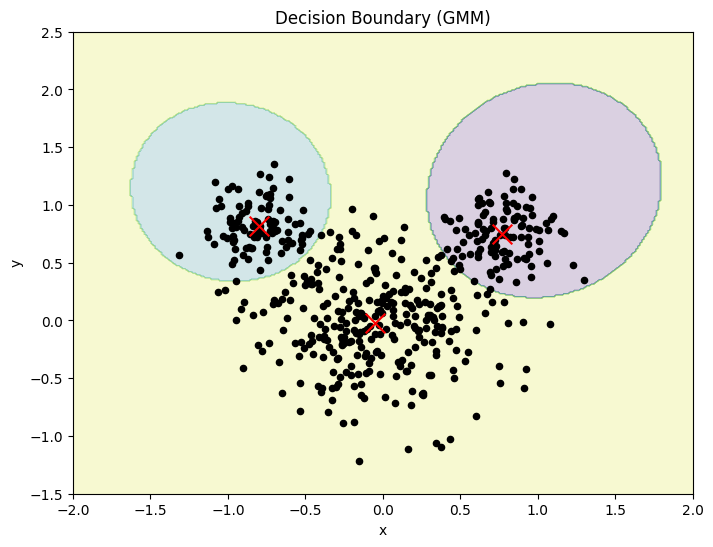

In [54]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(data_X)

x = np.linspace(-2, 2, 300)
y = np.linspace(-1.5, 2.5, 300)
xx, yy = np.meshgrid(x, y)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = gmm.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.2)
plt.scatter(data_X[:,0], data_X[:,1], s=20, c='black')
plt.scatter(gmm.means_[:,0], gmm.means_[:,1],
            c='red', marker='x', s=200)

plt.title("Decision Boundary (GMM)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

The boundaries produce circular regions as expected - the clusters are supposed to represent samples from gaussian distributions. Some points belong to the yellow cluster even though they are much closer to the red/blue mean that to the yellow mean but this is also expected because the posterior probability is not exactly equivalent to distance from the mean value.

We see two blue ellipses and a background yellow color. That is because the blue and red variables have much smaller variance than the yellow one so their densities vanish faster. They however don't vanish instantly which explains the empty blue and red spaces behind the main bulks of data points.

### Task 2

In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [56]:
def gen_data(k):
    samples = []
    for i in range(k):
        mean = (np.random.rand(2) - [0.5, 0.5]) * 10.0
        var = np.random.rand() / 5.0 + 0.1
        cov = np.array([[var, 0],
                        [0, var]])
        cnt = np.random.randint(100, 200)
        data = np.random.multivariate_normal(mean, cov, cnt)
        samples.append(data)
    return np.vstack(samples)

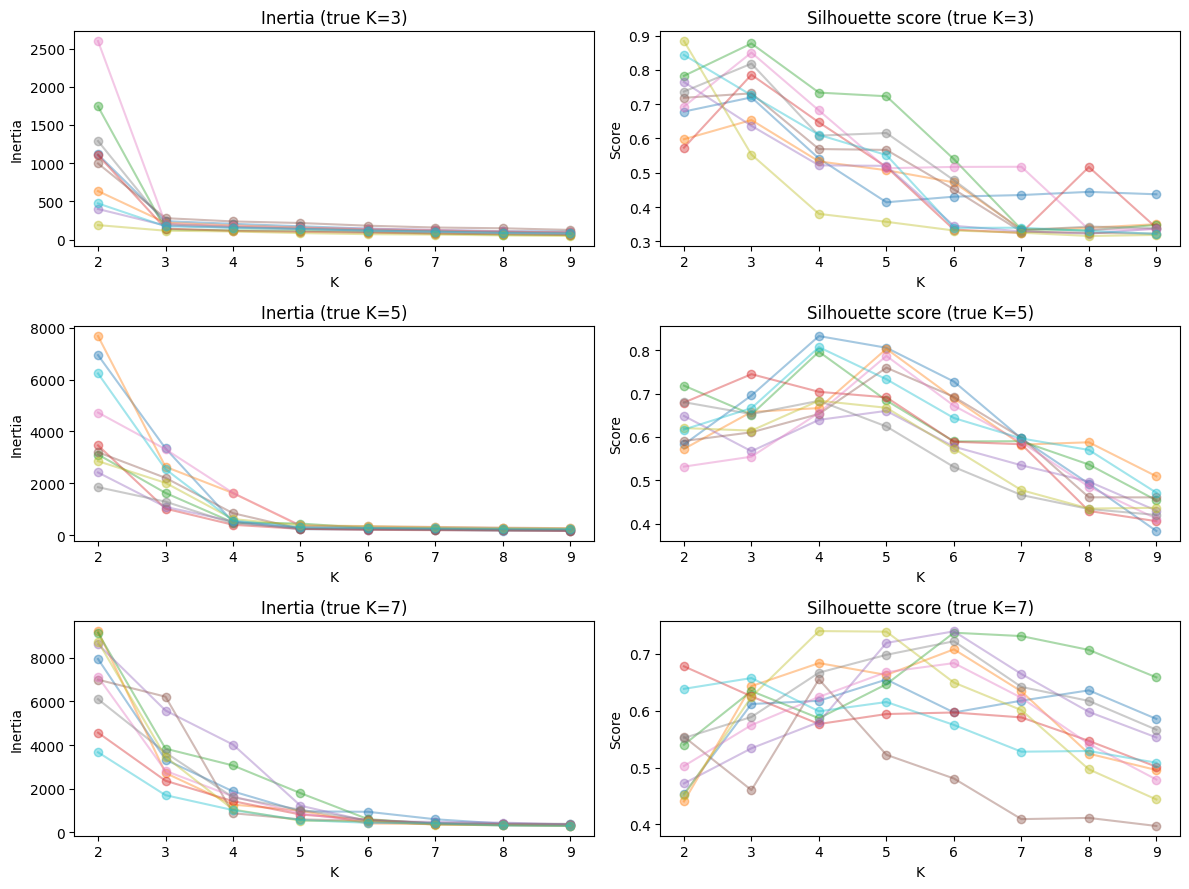

In [57]:
Ks_og = [3, 5, 7]
Ks = range(2, 10)
n_datasets = 10

plt.figure(figsize=(12,9))

for i, k_og in enumerate(Ks_og):
    plt.subplot(len(Ks_og), 2, 2*i + 1)
    plt.title(f"Inertia (true K={k_og})")
    plt.xlabel("K")
    plt.ylabel("Inertia")

    plt.subplot(len(Ks_og), 2, 2*i + 2)
    plt.title(f"Silhouette score (true K={k_og})")
    plt.xlabel("K")
    plt.ylabel("Score")

    for d in range(n_datasets):
        inertia = []
        silhouette = []
        data_X = gen_data(k_og)

        for k in Ks:
            km = KMeans(n_clusters=k, random_state=42)
            labels = km.fit_predict(data_X)

            inertia.append(km.inertia_)
            silhouette.append(silhouette_score(data_X, labels))

        plt.subplot(len(Ks_og), 2, 2*i + 1)
        plt.plot(Ks, inertia, marker='o', alpha=0.4)

        plt.subplot(len(Ks_og), 2, 2*i + 2)
        plt.plot(Ks, silhouette, marker='o', alpha=0.4)

plt.tight_layout()
plt.show()

To determine proper $k$ we can plot the inertia and silhouette score for different $k$'s. The inertia is a decreasing function with respect to $k$ but we could look for $k$ such that there are no more big improvements from using a bigger one. The silhouette score reflects both the compactness within clusters and how well separated they are. The bigger the silhouette score is the better the clasterization. This can greatly limit the number of $k$'s to consider.

The plots above show that this method may be helpful but definitely is not sufficient, especially if there are many overlapping samples.